# 05 — Modelado: XGBoost

## Objetivo
Construir un modelo de Machine Learning con XGBoost para predecir ventas,
incorporando todas las variables creadas en el Feature Engineering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# Carga del dataset con features
train = pd.read_csv('../data/processed/train_features.csv')
train['date'] = pd.to_datetime(train['date'])

# Filtrar GROCERY I - Tienda 1
df = train[(train['store_nbr'] == 1) & 
           (train['family'] == 'GROCERY I')].copy()

print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Shape: (1684, 20)
Columnas: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'dia_semana', 'mes', 'año', 'trimestre', 'dia_mes', 'semana_año', 'es_fin_de_semana', 'lag_7', 'lag_14', 'lag_28', 'rolling_7', 'rolling_28', 'dcoilwtico', 'es_feriado']


## 1. Preparación de Features

In [2]:
# Features que va a usar el modelo
features = ['dia_semana', 'mes', 'año', 'trimestre', 'dia_mes', 
            'semana_año', 'es_fin_de_semana', 'lag_7', 'lag_14', 
            'lag_28', 'rolling_7', 'rolling_28', 'dcoilwtico', 
            'es_feriado', 'onpromotion']

target = 'sales'

# Eliminar filas con NaN en los features de lag y rolling
df_model = df[features + [target, 'date']].dropna()

print(f"Dataset original:  {len(df)} filas")
print(f"Dataset sin NaN:   {len(df_model)} filas")
print(f"Filas eliminadas:  {len(df) - len(df_model)}")
print(f"\nFeatures utilizados: {len(features)}")

Dataset original:  1684 filas
Dataset sin NaN:   1656 filas
Filas eliminadas:  28

Features utilizados: 15


### 📝 Interpretación

El dataset preparado para XGBoost cuenta con 15 features y 1.656 filas válidas. 
Se eliminaron 28 filas (menos del 2% del total) correspondientes a los primeros 
días de la serie donde no era posible calcular los lags y promedios móviles por 
falta de historial previo. Esta pérdida es mínima y esperada, tal como se documentó 
en el ADR. Los 15 features cubren cuatro dimensiones del problema: patrones 
temporales (día, mes, trimestre), historial de ventas (lags y rolling), 
contexto macroeconómico (precio del petróleo) y eventos especiales (feriados y promociones).

## 2. División Train / Test

In [3]:
# División temporal — últimos 30 días para test
fecha_corte = df_model['date'].max() - pd.Timedelta(days=30)

train_df = df_model[df_model['date'] <= fecha_corte]
test_df = df_model[df_model['date'] > fecha_corte]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print(f"Train: {train_df['date'].min().date()} → {train_df['date'].max().date()} ({len(train_df)} días)")
print(f"Test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} ({len(test_df)} días)")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Train: 2013-01-29 → 2017-07-16 (1626 días)
Test:  2017-07-17 → 2017-08-15 (30 días)

X_train shape: (1626, 15)
X_test shape:  (30, 15)


## 3. Entrenamiento del Modelo XGBoost

In [4]:
# Entrenamiento XGBoost
modelo_xgb = XGBRegressor(
    n_estimators=500,        # cantidad de árboles
    learning_rate=0.05,      # velocidad de aprendizaje
    max_depth=5,             # profundidad máxima de cada árbol
    subsample=0.8,           # porcentaje de filas por árbol
    colsample_bytree=0.8,    # porcentaje de features por árbol
    random_state=42          # reproducibilidad
)

modelo_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## 4. Predicción y Evaluación

=== MÉTRICAS XGBOOST ===
MAE:  303.79
RMSE: 416.00
MAPE: 13.03%


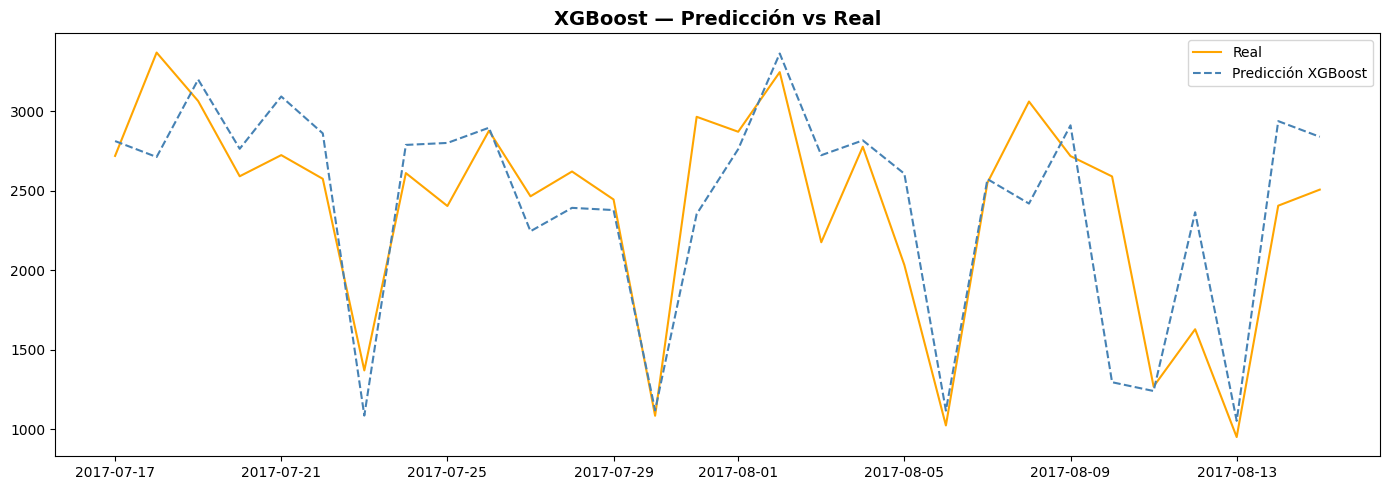

In [5]:
# Predicción
predicciones_xgb = modelo_xgb.predict(X_test)

# Métricas
def calcular_metricas(real, predicho):
    mae = np.mean(np.abs(real - predicho))
    rmse = np.sqrt(np.mean((real - predicho) ** 2))
    mask = real != 0
    mape = np.mean(np.abs((real[mask] - predicho[mask]) / real[mask])) * 100
    return mae, rmse, mape

mae, rmse, mape = calcular_metricas(y_test.values, predicciones_xgb)

print("=== MÉTRICAS XGBOOST ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Visualización
plt.figure(figsize=(14, 5))
plt.plot(test_df['date'].values, y_test.values, 
         color='orange', linewidth=1.5, label='Real')
plt.plot(test_df['date'].values, predicciones_xgb, 
         color='steelblue', linewidth=1.5, linestyle='--', label='Predicción XGBoost')
plt.title('XGBoost — Predicción vs Real', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/10_xgboost_prediccion.png', dpi=150)
plt.show()

### 📝 Interpretación

XGBoost obtuvo el mejor MAPE (13.03%), superando levemente a Prophet (13.15%) y 
ampliamente a SARIMA (17.27%). El gráfico muestra que XGBoost captura con mayor 
precisión tanto los picos como las caídas bruscas de la serie. Esta mejora se debe 
principalmente a los features de lag y rolling creados en el Feature Engineering, 
que le permiten al modelo aprender directamente del historial reciente de ventas. 
Prophet fue superior en MAE y RMSE, lo que indica que comete menos errores absolutos 
grandes, ambos modelos son complementarios.

## 5. Feature Importance

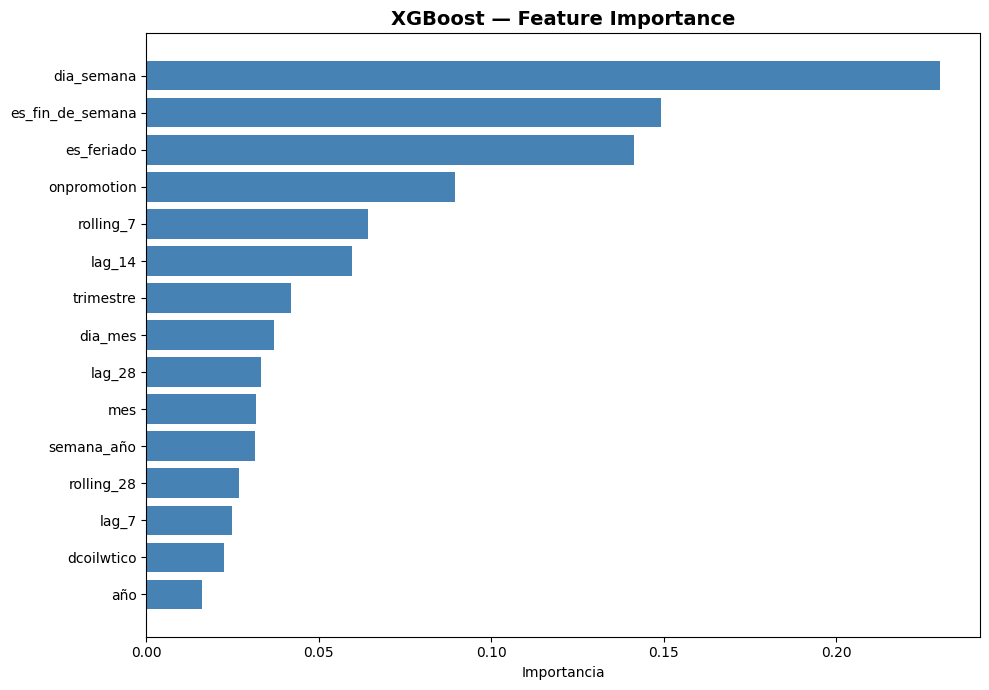


Top 5 features más importantes:
             feature  importancia
0         dia_semana     0.230272
6   es_fin_de_semana     0.149338
13        es_feriado     0.141529
14       onpromotion     0.089586
10         rolling_7     0.064355


In [6]:
# Feature Importance
importancias = pd.DataFrame({
    'feature': features,
    'importancia': modelo_xgb.feature_importances_
}).sort_values('importancia', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(importancias['feature'], importancias['importancia'], color='steelblue')
plt.title('XGBoost — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('../reports/figures/11_feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 features más importantes:")
print(importancias.sort_values('importancia', ascending=False).head())

### 📝 Interpretación

El feature importance confirma y valida los hallazgos del EDA. El día de la semana 
es el predictor más poderoso con un 23% de importancia, seguido por el indicador 
de fin de semana (15%) y feriado (14%), juntos explican más del 50% del poder 
predictivo del modelo. Esto valida la decisión de crear estas variables en el 
Feature Engineering. Las promociones (onpromotion) ocupan el cuarto lugar con 9%, 
lo que sugiere que en una versión futura del modelo sería valioso incorporar 
información anticipada de promociones planificadas. El precio del petróleo aparece 
con importancia baja pero presente, confirmando su relevancia como variable 
macroeconómica de contexto.